Panaroo Structural Variants in a Clonal Group (struct `.Rtab`)

`struct_presence_absence.Rtab` is tab-separated with header `Gene` then sample IDs: **rows = structural variant IDs**, **columns = 0/1 presence** (Panaroo). AnnData uses **obs = samples**, **var = variants**, so we **transpose** after read.

Pandas: `pd.read_csv(path, sep="\t", index_col=0)` — much faster than the CSV because cells are numeric, not long strings.

For the **full gene** binary matrix (not only structural variants), point `rtab_path` at `gene_presence_absence.Rtab` (same format).

**Note:** Structural variants are a **subset** of pangenome signal vs all genes — choose the file that matches your question.

In [1]:
%reload_ext autoreload
%autoreload 2

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
#import anndata as ad

from predict_kleb_by_bacformer.tl.panaroo_pangenome_features import (
    feature_frequency_distribution,
    features_per_sample,
    filter_by_prevalence,
    per_sample_counts_core_shell_cloud,
)

In [2]:
strain = "CG14"
CORE_FREQ = 0.95
CLOUD_FREQ = 0.05
FILTER_CUTOFF = 10

In [3]:
project_k_dir = "/home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/"
panaroo_dir = project_k_dir + "processed/panaroo_run/"
strain_dir = panaroo_dir + strain + "_all" + "/"

rtab_path = strain_dir + "gene_presence_absence.Rtab"

struct_df = pd.read_csv(rtab_path, sep="\t", index_col=0)
struct_df.columns = struct_df.columns.astype(str)

n_variants, n_samples = struct_df.shape
print(f"Loaded {rtab_path}")
print(f"  variants (rows): {n_variants},  samples (cols): {n_samples}")

Loaded /home/dca36/rds/rds-floto-bacterial-4k08a2yyQLw/david/processed/panaroo_run/CG14_all/gene_presence_absence.Rtab
  variants (rows): 14809,  samples (cols): 2232


Present genes (panaroo) per sample (column sums)
  n_samples: 2232
  min:  4213 genes per sample
  max:  5310 genes per sample
  mean: 4664.48 genes per sample
  sd:   142.40 genes per sample


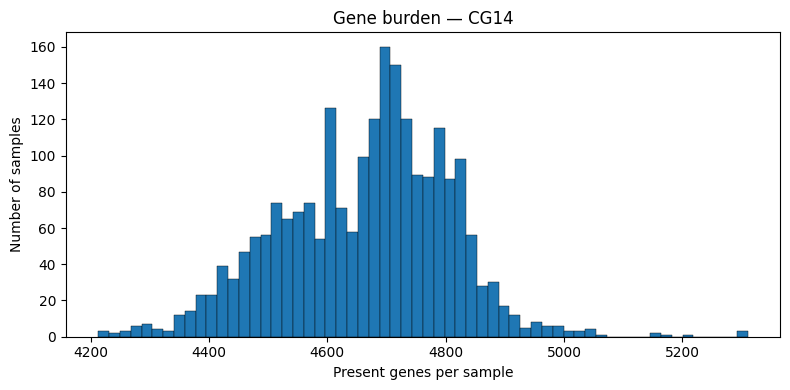

In [11]:
fps = features_per_sample(struct_df, strain, feature_label="gene")

Total genes: 14809
  Core  (>95% samples):    4018  (27.1%)
  Shell (5–95%):           2149  (14.5%)
  Cloud (<5%):             8642  (58.4%)
  Panaroo cutoff (<0.01%):       6921  (46.7%)
  Ubiquitous (100%):                2547  (17.2%)


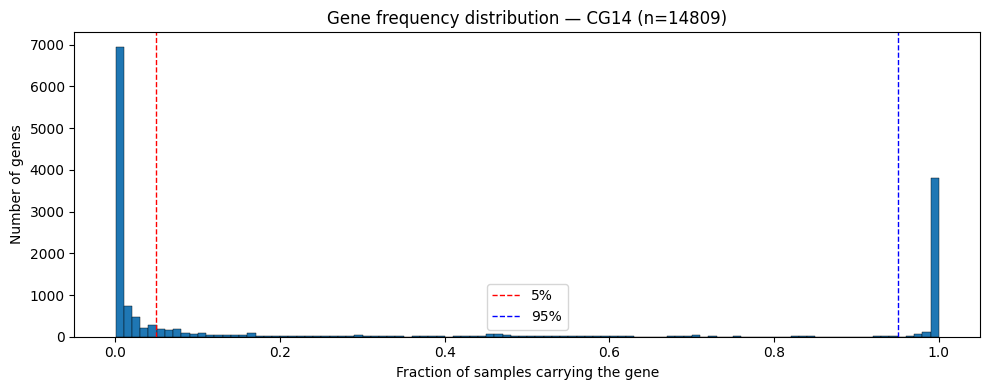

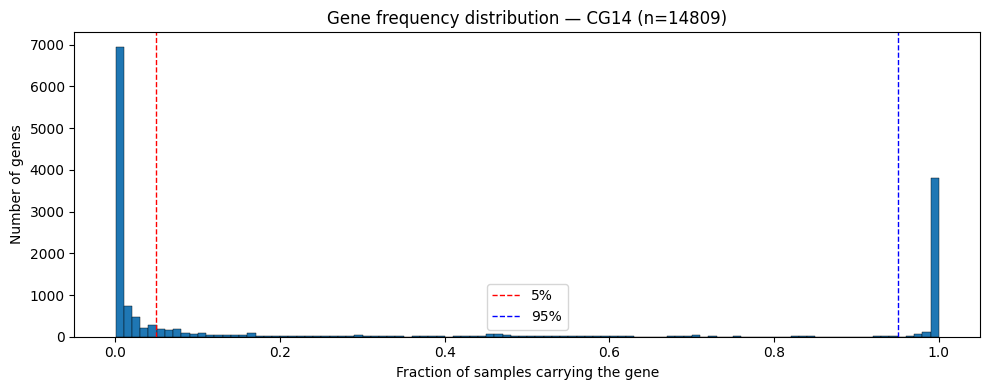

In [5]:
res = feature_frequency_distribution(
    struct_df, strain, feature_label="gene", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

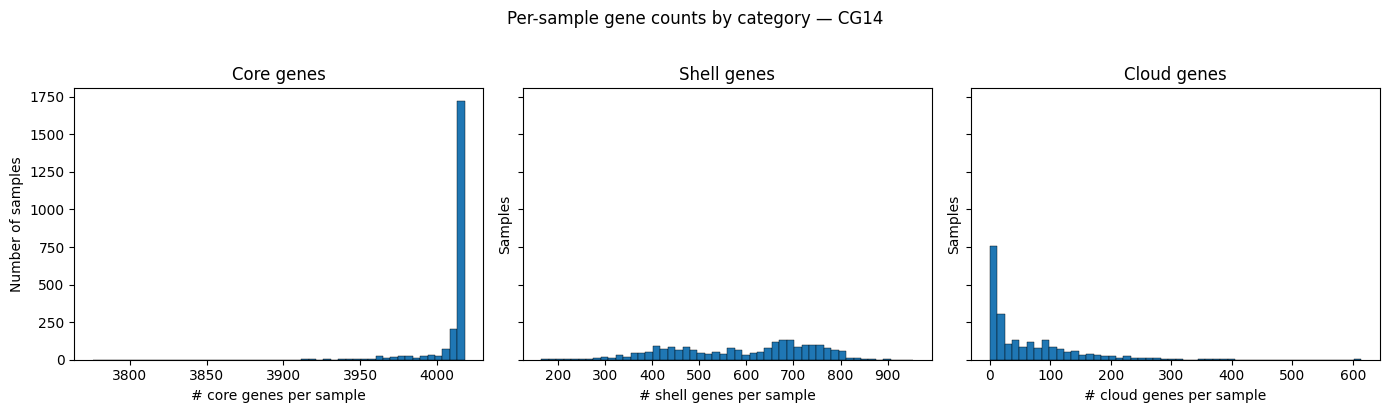

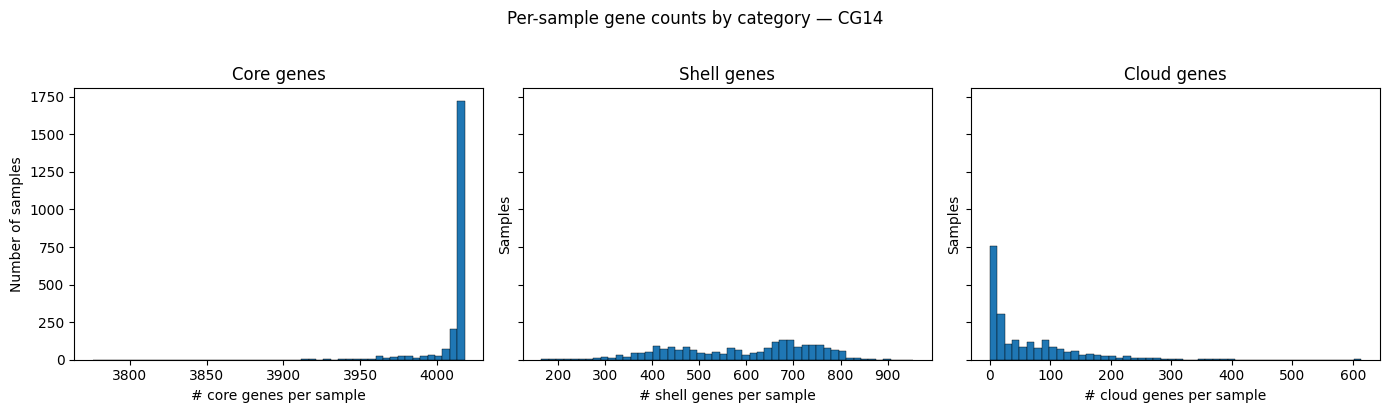

In [6]:
res = per_sample_counts_core_shell_cloud(
    struct_df, strain, feature_label="gene", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

In [7]:
res = struct_df_filt = filter_by_prevalence(
    struct_df, min_prevalence=FILTER_CUTOFF, feature_label="gene"
)

filter_by_prevalence (gene): 14809 -> 9347 features (min_prevalence=10 samples)


Present genes (panaroo) per sample (column sums)
  n_samples: 2232
  min:  4205 genes per sample
  max:  5154 genes per sample
  mean: 4656.66 genes per sample
  sd:   138.58 genes per sample


FeaturePerSampleResult(fig=<Figure size 800x400 with 1 Axes>, counts_per_sample=SAMD00055755                            4593
SAMD00055756                            4751
SAMD00055757                            4604
SAMD00055758                            4744
SAMD00055759                            4604
                                        ... 
GCF_011742055.2_ASM1174205v2_genomic    4840
GCF_026427375.1_ASM2642737v1_genomic    4719
GCF_034479915.1_ASM3447991v1_genomic    4667
GCF_019286855.1_ASM1928685v1_genomic    4873
GCF_019317205.1_ASM1931720v1_genomic    4872
Length: 2232, dtype: int64, n_samples=2232)

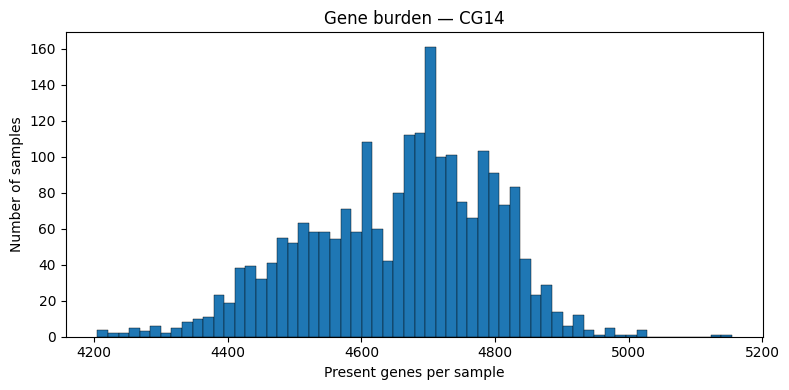

In [8]:
features_per_sample(struct_df_filt, strain, feature_label="gene")

Total genes: 9347
  Core  (>95% samples):    4018  (43.0%)
  Shell (5–95%):           2149  (23.0%)
  Cloud (<5%):             3180  (34.0%)
  Panaroo cutoff (<0.01%):       1459  (15.6%)
  Ubiquitous (100%):                2547  (27.2%)


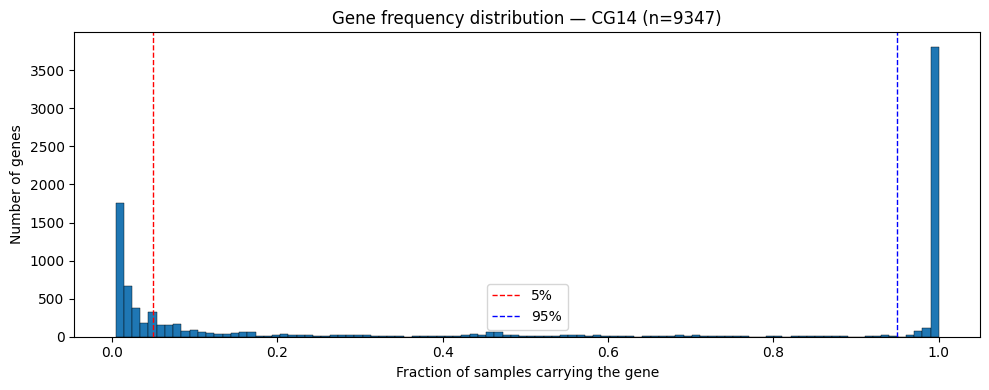

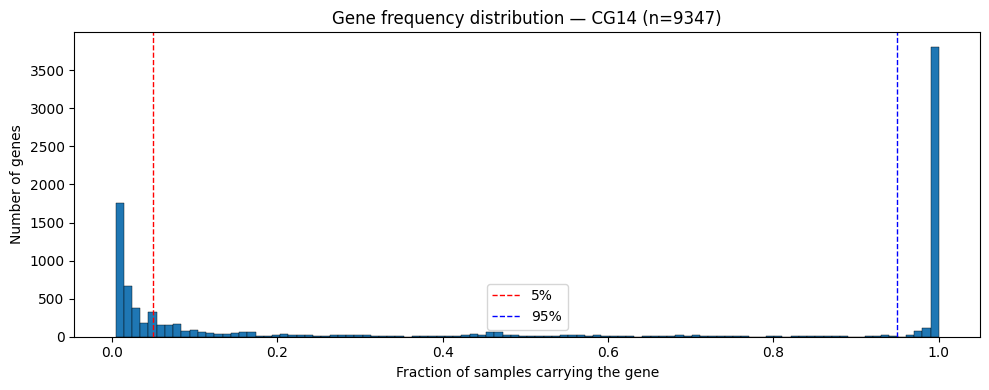

In [9]:
res =feature_frequency_distribution(
    struct_df_filt, strain, feature_label="gene", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

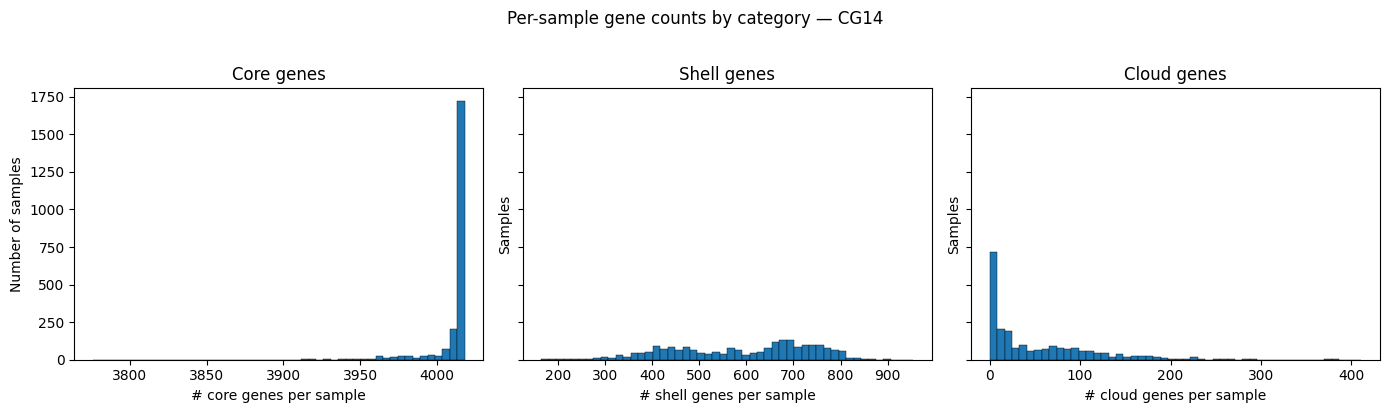

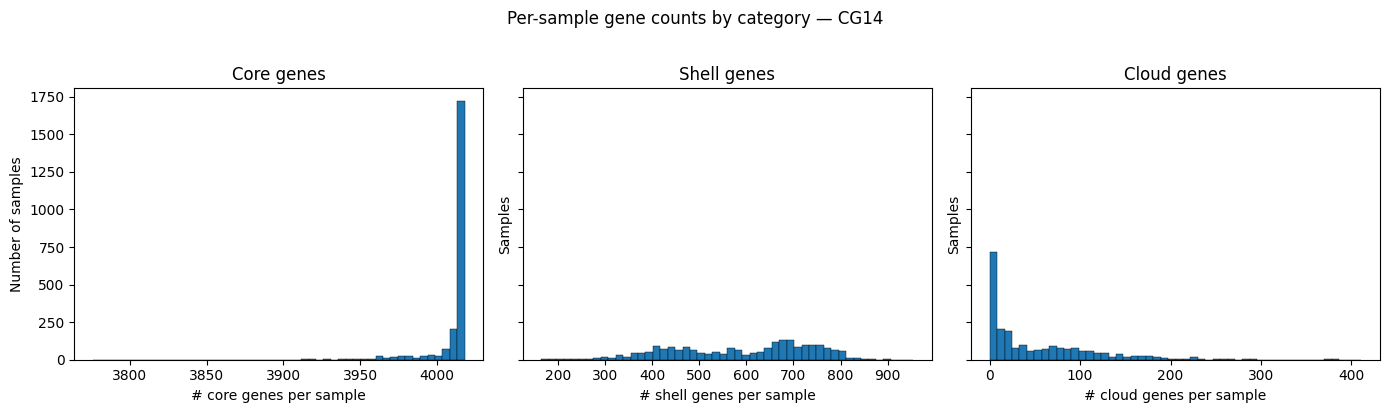

In [10]:
res = per_sample_counts_core_shell_cloud(
    struct_df_filt, strain, feature_label="gene", shell_low=CLOUD_FREQ, core_high=CORE_FREQ
)

In [14]:
# Look at the rare genes and see how they are coded (e.g. "NA" or "N/A", "0", etc)
rare_genes = struct_df[struct_df.sum(axis=1) < 10]
rare_genes.head()


,SAMD00055755,SAMD00055756,SAMD00055757,SAMD00055758,SAMD00055759,SAMD00055760,SAMD00055787,SAMD00055788,SAMD00055795,SAMD00055798,...,GCF_019286455.1_ASM1928645v1_genomic,GCF_019286695.1_ASM1928669v1_genomic,GCF_019317045.1_ASM1931704v1_genomic,GCF_001709275.1_ASM170927v1_genomic,GCF_003069525.1_ASM306952v1_genomic,GCF_011742055.2_ASM1174205v2_genomic,GCF_026427375.1_ASM2642737v1_genomic,GCF_034479915.1_ASM3447991v1_genomic,GCF_019286855.1_ASM1928685v1_genomic,GCF_019317205.1_ASM1931720v1_genomic
Gene,,,,,,,,,,,,,,,,,,,,,
group_11024,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_11023,1,1,0,1,1,1,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_10772,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_10382,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
group_10380,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
